In [145]:
# EN: Library imports
# FR: Importation des librairies
import numpy as np
import math
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import norm
from matplotlib.ticker import MultipleLocator

In [146]:
# =============================================================================
# EN: Step 1: Parameter initialisation
#     sigma and r are annual values, so T must be in years for consistency
# FR: Etape 1 : Initialisation des paramètres
#     sigma et r sont des valeurs annuelles donc T est en années pour être cohérent
# =============================================================================
def parameters(T, r, sigma, N):
    # EN: duration of one time step
    # FR: durée d'un pas
    dt = T / N
    # EN: up factor
    # FR: valeur haute
    h = np.exp(r*dt + sigma*np.sqrt(dt))
    # EN: down factor
    # FR: valeur basse
    b = np.exp(r*dt - sigma*np.sqrt(dt))
    # EN: risk-neutral probability
    #     the NAO condition is satisfied by construction of h and b
    # FR: probabilité risque-neutre
    #     la condition NAO est respectée par construction de h et b
    pi = (np.exp(r*dt) - b) / (h - b)
    return dt, h, b, pi

In [147]:
# =============================================================================
# EN: Step 2: Construction of the underlying asset price tree
# FR: Etape 2 : Création de l'arbre des prix d'un sous-jacent
# =============================================================================
def price_tree(S, h, b, N):
    # EN: creation of a zero-filled matrix in which the tree values will be stored
    # FR: création d'une matrice remplie de zéros dans laquelle on va stocker les valeurs de l'arbre
    M = np.zeros((N+1, N+1))
    # EN: iterate over columns
    # FR: on parcourt les colonnes
    for i in range(N+1):
        # EN: iterate over rows
        # FR: on parcourt les lignes
        for j in range(i+1):
            # EN: the stock price at column i, row j
            # FR: le prix de l'action à la colonne i, ligne j
            M[j, i] = S * (h**j) * (b**(i-j))
    return M

In [148]:
# =============================================================================
# EN: Step 3: Computation of the option value for the underlying
#     Function that returns the payoff depending on whether the option is a call or a put
# FR: Etape 3 : Calcul de la valeur de l'option associée au sous-jacent
#     Création d'une fonction qui change le payoff selon que ce soit un call ou un put
# =============================================================================
def payoff(S, K, option_type):
    if option_type == "call":
        return max(S - K, 0)
    elif option_type == "put":
        return max(K - S, 0)

In [149]:
# =============================================================================
# EN: Method 1: Closed-form formula (eq. 2.4, page 59 of the reference book)
# FR: Méthode 1 : Par une formule close (eq 4 page 57 du livre de référence)
# =============================================================================
def option_value1(S, K, r, T, h, b, pi, N, option_type):
    total = 0
    for j in range(0, N+1):
        S_node = (h**j) * (b**(N-j)) * S
        # EN: eq. (2.4) without discounting
        # FR: eq (4) sans l'actualisation
        total += math.comb(N, j) * (pi**j) * ((1-pi)**(N-j)) * payoff(S_node, K, option_type)
    # EN: with discounting applied
    # FR: avec l'actualisation
    return np.exp(-r*T) * total

In [150]:
# =============================================================================
# EN: Method 2: Backward induction on the tree (used for American options)
#     we add the possibility that the option is American
# FR: Méthode 2 : En remontant l'arbre (utilisée pour les options américaines)
#     on ajoute la possibilité que ce soit une option américaine
# =============================================================================
def option_value2(M, K, r, dt, pi, N, option_type, american=False):
    # EN: creation of a zero-filled matrix of the same size as the price tree matrix
    #     used to store the option values at each node of the tree
    # FR: création d'une matrice remplie de zéros, de même taille que la matrice de l'arbre
    #     utilisée pour stocker les valeurs de l'option à chaque noeud
    V = np.zeros(np.shape(M))

    # EN: we fill the matrix from the end, starting at maturity
    #     (formula for C on page 4, or equivalently in eq. (2.4) on page 59)
    #     moreover, the formula is implicitly used through the matrix M
    #     since all computations have already been carried out
    # FR: on remplit la matrice par la fin en commençant par la maturité
    #     (formule du C page 9 ou aussi dans l'eq (4) page 57)
    #     par ailleurs la formule est implicitement utilisée à travers la matrice M
    #     car tous les calculs ont déjà été faits
    for j in range(0, N+1):
        V[j, N] = payoff(M[j, N], K, option_type)

    # EN: we go back up the tree columns from right to left
    # FR: on remonte les colonnes de l'arbre
    for i in range(N-1, -1, -1):
        # EN: we fill all rows
        # FR: on remplit toutes les lignes
        for j in range(0, i+1):
            # EN: eq. (1.4) from page 4
            # FR: eq (2) de la page 9
            discounted_value = np.exp(-r*dt) * ((pi * V[j+1, i+1]) + (1-pi) * V[j, i+1])
            if not american:
                # EN: since the tree is recombining, the transition from the up state to the next state
                #     is at index j+1,i+1, whereas the down state is at j, i+1
                # FR: l'arbre étant recombinable, le passage de l'état haut à l'état d'après
                #     se trouve en j+1,i+1, alors que l'état bas se trouve en j, i+1
                V[j, i] = discounted_value
            else:
                # EN: either we exercise now, or we wait
                # FR: soit on sort maintenant, soit on attend
                V[j, i] = max(payoff(M[j, i], K, option_type), discounted_value)

    # EN: returns the option price today and the matrix of all option values at each node
    # FR: retourne le prix de l'option aujourd'hui et la matrice composée de toutes les valeurs de l'option
    return V[0, 0], V

In [151]:
# =============================================================================
# EN: We look for for the exercise boundary
#     We look for nodes where exercise is optimal (optimal exercise region E (4.8))
# FR: On cherche la frontière d'exercice
#     On cherche les points où l'on exerce (région d'exercice optimale E (4.8))
# =============================================================================
def snell_envelope(M, K, r, dt, pi, N, option_type):
    # EN: we retrieve the option values at each node
    # FR: on récupère les valeurs de l'option à chaque noeud
    V_0, V = option_value2(M, K, r, dt, pi, N, option_type, american=True)

    # EN: initialisation of the Boolean matrix
    #     its purpose is to determine whether, at each node, immediate exercise is optimal
    #     it has the same size as M and is initialised to "False"
    # FR: initialisation de la matrice booléenne
    #     son but est de savoir si, pour chaque noeud, il est optimal d'exercer
    #     elle a la même taille que M et est remplie de "False"
    exercise = np.full(np.shape(M), False)

    # EN: we traverse the tree to identify nodes where exercise is advantageous
    # FR: on parcourt l'arbre pour identifier les points où il est intéressant d'exercer
    for i in range(N+1):
        for j in range(i+1):
            # EN: the gain obtained if we exercise the option at node (j,i)
            # FR: ce que l'on gagne si on exerce l'option au noeud (j,i)
            immediate_gain = payoff(M[j, i], K, option_type)
            # EN: we search for the optimal exercise region (these are all the green nodes of the tree)
            #     np.isclose is used to avoid rounding errors
            #     the second condition ensures that K > S (for a put)
            #     the issue would be: if S >= K (immediate_gain == 0) and the expected next-day gain is also 0,
            #     the condition returns "True" even though exercise is not optimal (since gain = 0)
            # FR: on cherche la région d'exercice optimale (il s'agit de tous les points verts de l'arbre)
            #     np.isclose pour éviter les erreurs d'arrondis
            #     la deuxième condition assure que K > S (pour un put)
            #     le problème serait que si on a S >= K (gain_immediat == 0) et si en moyenne on gagne 0
            #     au jour suivant, alors cela renvoie "True" mais il n'est pas optimal d'exercer (car gain = 0)
            if np.isclose(V[j, i], immediate_gain) and immediate_gain > 0:
                # EN: we have found a node where exercise is advantageous
                # FR: on a trouvé un point où il est intéressant d'exercer
                exercise[j, i] = True

    # EN: the set of nodes where the option should be exercised (this is the optimal exercise region E)
    # FR: l'ensemble des noeuds où il faut exercer l'option (c'est la région d'exercice optimale E)
    return exercise

In [152]:
# =============================================================================
# EN: Among the nodes where exercise is optimal, we identify those on the boundary
# FR: On cherche, parmi les points où l'on exerce, les points sur la frontière
# =============================================================================
def exercise_boundary(M, exercise, N, option_type):
    # EN: this is the x-axis (here representing time steps / trading days)
    # FR: il s'agit de l'axe des abscisses (ici ce sont des jours)
    time_steps = []
    # EN: this is the y-axis (here representing the stock price)
    # FR: il s'agit de l'axe des ordonnées (ici c'est le prix de l'action)
    boundary_prices = []

    for i in range(N+1):
        # EN: we look for row indices j in column i where exercise[j,i] is True
        #     "[0]" extracts the first array from the tuple returned by np.where
        #     i.e. all nodes where exercise is optimal
        # FR: on cherche les indices j dans la colonne i où exercise[j,i] est True
        #     le "[0]" permet de prendre le 1er tableau du tuple renvoyé par np.where
        #     c'est-à-dire tous les noeuds où on exerce
        exercise_indices = np.where(exercise[:i+1, i] == True)[0]

        # EN: we check that there exist indices where exercise[j,i] is True
        # FR: on s'assure qu'il existe des indices où exercise[j,i] est True
        if len(exercise_indices) > 0:
            # EN: we add the x-coordinate of the boundary point (used for plotting)
            # FR: on ajoute l'abscisse du point de la frontière (cela servira pour l'affichage)
            time_steps.append(i)
            if option_type == 'put':
                # EN: for a put, we take the largest index because
                #     the boundary corresponds to the highest price among exercise nodes
                # FR: pour un put, on prend l'indice le plus grand car
                #     la frontière est le prix le plus haut parmi les noeuds d'exercice
                boundary = np.max(exercise_indices)
            else:
                # EN: for a call, we take the smallest index because
                #     the boundary corresponds to the lowest price among exercise nodes
                # FR: pour un call, on prend l'indice le plus petit car
                #     la frontière est le prix le plus bas parmi les noeuds d'exercice
                boundary = np.min(exercise_indices)
            # EN: we identify the price in the price matrix corresponding to the boundary node
            # FR: on identifie le prix dans la matrice des prix correspondant au noeud
            boundary_prices.append(M[boundary, i])

    return time_steps, boundary_prices

In [153]:
# =============================================================================
# EN: We visualise the optimal exercise region and its boundary
# FR: On visualise la région ainsi que sa frontière
# =============================================================================
def visualize_snell(M, exercise, N, K, option_type):
    # EN: we extract the boundary
    # FR: on extrait la frontière
    time_steps, boundary_prices = exercise_boundary(M, exercise, N, option_type)

    # EN: we plot the boundary
    #     the boundary is plotted as a function of time, which is why we use the time_steps list
    # FR: on trace la frontière
    #     on trace la frontière en fonction du temps, ce qui explique l'utilisation de la liste time_steps
    plt.plot(time_steps, boundary_prices, color='violet', linewidth=2,
             label='Optimal exercise boundary')

    # EN: we highlight the nodes on the boundary
    # FR: on met en avant les noeuds sur la frontière
    plt.scatter(time_steps, boundary_prices, color='black', zorder=3)

    # EN: we shade the exercise region (optimal exercise region)
    # FR: on remplit la zone où l'on exerce (la région d'exercice optimale)
    if option_type == 'put':
        # EN: we shade the exercise region for a put
        #     we colour between the minimum price points and the boundary
        # FR: on remplit la zone d'exercice pour un put
        #     on colorie entre les points minima et la frontière
        plt.fill_between(x=time_steps, y1=np.min(M), y2=boundary_prices,
                         color='green', alpha=0.5, label="Exercise region (Put)")
    else:
        # EN: for a call, we colour between the maximum price points and the boundary
        # FR: pour un call on colorie entre les points maxima et la frontière
        plt.fill_between(x=time_steps, y1=boundary_prices, y2=np.max(M),
                         color='green', alpha=0.5, label="Exercise region (Call)")

    # EN: we plot the strike price as a horizontal dashed line
    # FR: on trace le prix d'exercice
    plt.axhline(y=K, color='black', linestyle='--', alpha=0.5,
                label=f'Strike price K={K}')
    plt.title(f"Optimal exercise region and boundary ({option_type})")
    plt.xlabel("Steps")
    plt.ylabel("Asset price (S)")
    plt.legend()
    # EN: to leave some margin between the start and the end of the graph
    # FR: pour se laisser de la marge entre le début et la fin
    plt.xlim(0, N+1)
    # EN: on the y-axis of the current graph, we set the major tick interval (here 5)
    # FR: sur l'axe y du graphique actuel, on fixe le pas des grandes graduations (ici 5)
    plt.gca().yaxis.set_major_locator(MultipleLocator(5))
    plt.show()

In [154]:
# =============================================================================
# EN: We test put-call parity
# FR: On teste la parité put-call
# =============================================================================
def test_parity(S, K, r, T, h, b, pi, N):
    # EN: call price
    # FR: prix du call
    C = option_value1(S, K, r, T, h, b, pi, N, "call")
    # EN: put price
    # FR: prix du put
    P = option_value1(S, K, r, T, h, b, pi, N, "put")
    # EN: page 64 of the reference book
    # FR: page 61 du livre de référence
    left_side  = C - P
    right_side = S - K * np.exp(-r*T)
    print(f"C - P = {left_side:.4f}")
    print(f"S - Ke^(-rT) = {right_side:.4f}")
    # EN: we use np.isclose to allow for rounding errors
    # FR: on utilise np.isclose pour accepter des erreurs d'arrondis
    if np.isclose(left_side, right_side):
        return "Put-call parity is satisfied"
    else:
        return "Put-call parity is not satisfied"

In [155]:
# =============================================================================
# EN: Step 4: Tree visualisation
#     V, containing all option values at each node, is an optional parameter
# FR: Etape 4 : Visualisation de l'arbre
#     V, toutes les valeurs prises par l'option, est un paramètre optionnel
# =============================================================================
def visualize_tree(M, N, option_type, K, V=None):
    for i in range(N+1):
        # EN: iterate over columns (x-axis)
        # FR: on parcourt les colonnes (axe des abscisses)
        for j in range(i+1):
            # EN: iterate over rows (y-axis)
            #     colour coding: green if payoff is positive, red otherwise, black at the root node
            # FR: on parcourt les lignes (axe des ordonnées)
            #     ajout de couleurs : si la valeur du payoff est positive c'est vert, rouge sinon et noir à la racine
            if option_type == "call":
                if M[j, i] > K:
                    node_color = "green"
                elif M[j, i] == K:
                    node_color = "black"
                else:
                    node_color = "red"
            elif option_type == "put":
                if M[j, i] < K:
                    node_color = "green"
                elif M[j, i] == K:
                    node_color = "black"
                else:
                    node_color = "red"

            # EN: since the tree is recombining, we vertically centre node j, hence the -i/2 term
            #     zorder ensures nodes are displayed above the branches
            # FR: l'arbre étant recombinable, on recentre verticalement le noeud j, d'où l'apparition du -i/2
            #     zorder permet d'afficher les points au-dessus des branches
            plt.scatter(i, j - i/2, color=node_color, zorder=5)

            # EN: displays the underlying price rounded to 2 decimal places
            # FR: affiche le prix du sous-jacent; le "f..." arrondit à 2 décimales
            plt.text(i, j - i/2 + 0.15, f"{M[j,i]:.2f}", color="black",
                     fontsize=8, ha="center",
                     bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.7))

            if V is not None:
                # EN: displays the option values
                # FR: affiche les valeurs de l'option
                plt.text(i, j - i/2 - 0.18, f"{V[j,i]:.2f}", color="blue",
                         fontsize=8, ha="center",
                         bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.7))

            # EN: since there are no branches beyond the final date N
            # FR: car il n'y a pas de branches après N
            if i < N:
                # EN: we draw the up branch
                # FR: on trace la branche montante
                plt.plot([i, i+1], [j - i/2, j+1-(i+1)/2], color="green")
                # EN: down branch
                # FR: branche descendante
                plt.plot([i, i+1], [j - i/2, j-(i+1)/2], color="red")

    # EN: hides the axes
    # FR: cache les axes
    plt.axis("off")
    # EN: graph title
    # FR: le titre
    plt.title("Visualisation of the binomial tree in discrete model")
    # EN: adding a legend
    # FR: ajout d'une légende
    plt.text(0.01, 0.01, "■ Underlying price",
             color="black", fontsize=8, transform=plt.gca().transAxes)
    if V is not None:
        plt.text(0.01, 0.05, "■ Option value",
                 color="blue", fontsize=8, transform=plt.gca().transAxes)
    plt.show()

In [156]:
# =============================================================================
# EN: Black-Scholes implementation
#     Visualisation of the convergence of the discrete model towards continuous time
# FR: Implémentation de Black et Scholes
#     Visualisation de la convergence du modèle discret vers le temps continu
# =============================================================================
def black_scholes(S, K, r, T, sigma):
    # EN: formula from Theorem 2.6.4, page 64 of the reference book
    # FR: formule du théorème 2.6.3 page 61 du livre de référence
    d = (np.log(S/K) + r*T) / (sigma * np.sqrt(T)) + sigma * np.sqrt(T) / 2
    C = S * norm.cdf(d) - K * np.exp(-r*T) * norm.cdf(d - sigma * np.sqrt(T))
    return C

In [157]:
# =============================================================================
# EN: We plot the convergence of the binomial model towards the continuous-time model
# FR: On trace la convergence du modèle binomial vers le modèle à temps continu
# =============================================================================
def convergence(S, K, r, T, sigma, N_max):
    # EN: to store the option prices at each iteration
    # FR: pour stocker les prix de chaque itération
    binomial_prices = []

    for i in range(1, N_max+1):
        # EN: at each iteration, we update the parameters
        #     and we must rebuild the tree with the new N (which is i)
        #     then we compute the option price at iteration i
        # FR: à chaque itération, on met à jour les paramètres
        #     et il faut reconstruire l'arbre avec le nouveau N (qui est i)
        #     puis on calcule le prix à l'itération i
        dt, h, b, pi = parameters(T, r, sigma, i)
        M = price_tree(S, h, b, i)
        price, V = option_value2(M, K, r, dt, pi, i, "call")
        # EN: we store the option price
        # FR: on stocke le prix de l'option
        binomial_prices.append(price)

    # EN: we plot the binomial model price curve
    # FR: on trace la courbe du modèle binomial
    plt.plot(range(1, N_max+1), binomial_prices, color="blue", label="Binomial")
    # EN: we plot the Black-Scholes option price as a horizontal reference line
    # FR: on trace le prix de l'option avec Black-Scholes
    plt.plot(range(1, N_max+1), [black_scholes(S, K, r, T, sigma)] * N_max,
             color="red", label="Black-Scholes")
    plt.xlabel("Number of steps N")
    plt.ylabel("Call price")
    plt.title("Convergence of the binomial model towards Black-Scholes")
    plt.legend()
    plt.show()

In [158]:
# =============================================================================
# EN: Numerical application with reference parameters
# FR: Application avec les paramètres de référence
# =============================================================================
S, K, T, r, sigma, N = 100, 100, 1, 0.05, 0.2, 5

In [159]:
# EN: Parameter computation
# FR: Calcul des paramètres
dt, h, b, pi = parameters(T, r, sigma, N)

In [160]:
# EN: Construction of the price tree
# FR: Construction de l'arbre des prix
M = price_tree(S, h, b, N)

In [161]:
# EN: European call price (both methods must yield the same result)
# FR: Prix du call européen (les deux méthodes doivent donner le même résultat)
print(option_value1(S, K, r, T, h, b, pi, N, "call"))
price, V = option_value2(M, K, r, dt, pi, N, "call")
# EN: we verify that both values are equal
# FR: on vérifie que les valeurs sont égales
print(price)

10.602977946352347
10.602977946352352


In [162]:
# EN: Put-call parity verification
# FR: Vérification de la parité put-call
print(test_parity(S, K, r, T, h, b, pi, N))

C - P = 4.8771
S - Ke^(-rT) = 4.8771
Put-call parity is satisfied


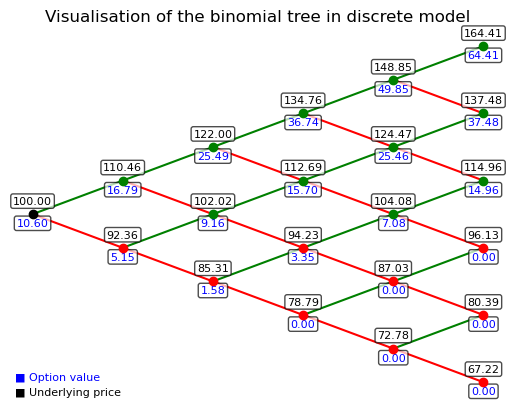

In [163]:
# EN: Tree visualisation with option values
# FR: Visualisation de l'arbre avec les valeurs de l'option
visualize_tree(M, N, "call", K, V)

10.450583572185565


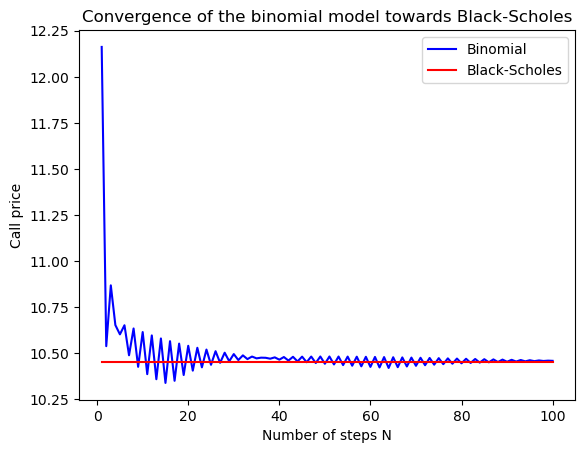

In [164]:
# EN: Convergence towards Black-Scholes
# FR: Convergence vers Black-Scholes
print(black_scholes(100, 100, 0.05, 1, 0.2))
convergence(S, K, r, T, sigma, N_max=100)

In [165]:
# EN: Comparison of European and American option prices
# FR: Comparaison du prix des options européennes et américaines
price_call_eu, _ = option_value2(M, K, r, dt, pi, N, "call", False)
price_call_am, _ = option_value2(M, K, r, dt, pi, N, "call", True)
price_put_eu,  _ = option_value2(M, K, r, dt, pi, N, "put",  False)
price_put_am,  _ = option_value2(M, K, r, dt, pi, N, "put",  True)

print(f"European call: {price_call_eu:.4f}")
# EN: the value is the same (expected for a non-dividend-paying asset)
# FR: la valeur est la même (attendu pour un actif sans dividende)
print(f"American call: {price_call_am:.4f}")
print(f"European put:  {price_put_eu:.4f}")
# EN: put prices differ: the American put is worth more
# FR: les prix des puts sont différents : le put américain vaut plus
print(f"American put:  {price_put_am:.4f}")

European call: 10.6030
American call: 10.6030
European put:  5.7259
American put:  6.2233


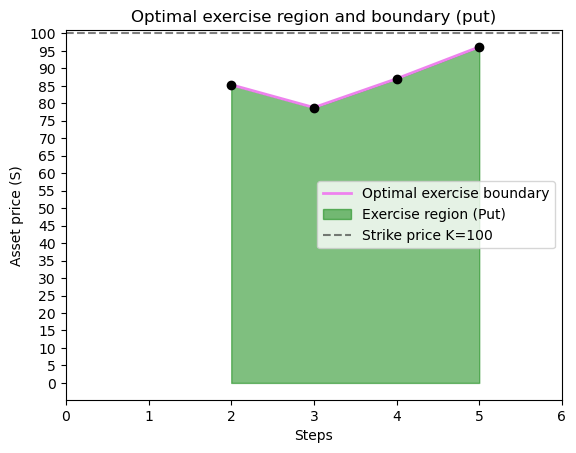

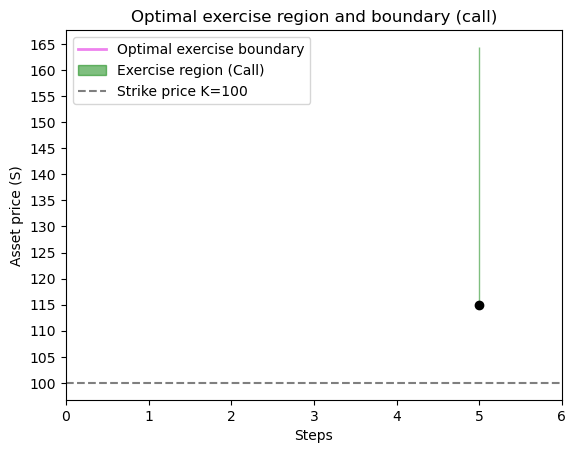

In [166]:
# EN: For a put
# FR: Pour un put
exercise1 = snell_envelope(M, K, r, dt, pi, N, 'put')
visualize_snell(M, exercise1, N, K, 'put')

# EN: For a call
# FR: Pour un call
exercise2 = snell_envelope(M, K, r, dt, pi, N, 'call')
visualize_snell(M, exercise2, N, K, 'call')

In [167]:
# =============================================================================
# EN: Comparison between the binomial model price and actual market data
# FR: Comparaison du prix d'une option entre le modèle binomial ci-dessus et la réalité
# =============================================================================

# EN: we load the data (Crédit Agricole stock prices from 18/01/2026 to 17/04/2026)
# FR: on charge les données (actions du Crédit Agricole entre le 18/01/2026 et le 17/04/2026)
df = pd.read_csv('Actions_Crédit_agricole_18.01-17.04.csv')

# EN: converts text to actual Python date objects, enabling chronological sorting
# FR: convertit le texte en vraies dates Python ce qui permet de les trier
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

# EN: we ensure dates are ordered from oldest to most recent
# FR: on s'assure que les dates sont du plus ancien au plus récent
df = df.sort_values('Date')

# EN: we remove spaces and replace decimal commas with decimal points
#     to avoid numerical parsing issues in subsequent computations
# FR: on remplace les espaces par "rien" et les virgules par des points
#     pour ne pas avoir de problèmes lors des calculs
df['Fermeture'] = df['Fermeture'].str.replace(' ', '').str.replace(',', '.')

# EN: converts the closing price column to numeric type
# FR: permet de voir les données comme des nombres
df['Fermeture'] = pd.to_numeric(df['Fermeture'])

prices = df['Fermeture']

# EN: we shift all prices down by one row to obtain the list of "yesterday's prices"
# FR: on décale tous les prix d'une ligne vers le bas afin de récupérer une liste des "prix d'hier"
df['Previous_Close'] = df['Fermeture'].shift(1)

# EN: we compute the list of log-returns
# FR: on crée la liste des log-rendements
df['log_returns'] = np.log(prices / df['Previous_Close'])

# EN: we remove rows containing "NaN"
#     this is done for the first row since after shifting, the first day has no "previous day"
# FR: on supprime les lignes où il y aurait "NaN"
#     ici, on fait ça pour la première ligne car quand on décale, le premier jour n'a pas de "jour d'avant"
df = df.dropna()

# EN: we compute the daily volatility
#     .std() computes the corrected (unbiased) standard deviation of the log-returns column
# FR: on calcule la volatilité "journalière"
#     .std() calcule l'écart-type corrigé, ici de la colonne contenant les log-rendements
daily_sigma = df['log_returns'].std()

# EN: we annualise the volatility
#     we assume daily returns are independent and that volatility is constant across days
# FR: on annualise la volatilité
#     on considère que les jours sont indépendants et que la volatilité est la même chaque jour
annual_sigma = daily_sigma * np.sqrt(252)

# EN: our volatility is based on historical data, whereas the one actually used in practice
#     (available on Société Générale's website) is the implied volatility, equal to 25.6%
#     our estimate is therefore reasonably consistent with the market figure
# FR: notre volatilité est basée sur l'historique passé, alors que celle utilisée en réalité
#     (trouvable sur le site de la Société Générale) est la volatilité implicite et vaut 25.6%
#     ainsi nous sommes plutôt cohérents
print(f"Annual volatility of Crédit Agricole stock: {annual_sigma:.2%}")

Annual volatility of Crédit Agricole stock: 28.02%


In [168]:
# EN: We compare with a European call warrant quoted at 0.140/0.150 on 18/04
#     Source: https://www.boursorama.com/bourse/produits-de-bourse/cours/warrants/3rPDE000SJ1SQ07
# FR: On compare avec un call européen avec un prix de 0.140/0.150 le 18/04
#     Source : https://www.boursorama.com/bourse/produits-de-bourse/cours/warrants/3rPDE000SJ1SQ07

# EN: S is the Crédit Agricole stock price on 17/04
#     the strike price is 18 euros
#     T is in years; the option matures on 19/06/2026
#     hence T = 43/252 (43 trading days out of 252) ≈ 0.171 years
#     for r we use the 3-month Euribor rate as of 18/04/2026
# FR: pour S il s'agit du prix de l'action le 17/04
#     le strike est à 18 euros
#     T est en années, la maturité de l'option est le 19/06/26
#     on fait donc 43/252 (43 jours de bourse sur 252) environ égal à 0,171 an
#     pour r on choisit l'Euribor 3 mois observé le 18/04/2026
S, K, T, r, sigma, N = 17.78, 18, 0.171, 0.02238, annual_sigma, 1000

dt, h, b, pi = parameters(T, r, sigma, N)
M = price_tree(S, h, b, N)
price, V = option_value2(M, K, r, dt, pi, N, "call")

# EN: we divide by 2 because the option parity (exercise ratio) is 2
#     this means that one warrant gives the right to buy half a share
#     therefore, to obtain the warrant price, we divide the call price by 2
#     since the right is worth half that of a standard option
#     the theoretical price differs from the observed market price:
#     the next dividend of 1.13 euros per share is to be paid on 26 May 2026,
#     which significantly impacts the option price (the model does not account for dividends)
# FR: on divise par 2 car la parité de l'option est de 2
#     cela signifie que l'on peut acheter une demi-action
#     ainsi pour obtenir le prix du warrant il faut diviser par 2
#     car le droit vaut deux fois moins cher qu'une option classique
#     on remarque que le prix obtenu n'est pas le prix attendu :
#     le prochain dividende sera versé le 26 mai à hauteur de 1,13 euros par action
#     ce qui impacte le prix de l'option (non pris en compte dans notre modèle)
print(price / 2)


0.37576896283595906
